#  Disaster Tweet Classification
## Notebook 2: Feature Engineering & Model Training
---
**Objective:** Train multiple classification models (Logistic Regression, Random Forest, Naive Bayes, XGBoost), tune hyperparameters, and select the best performer.

## 1. Import Libraries & Load Artefacts

In [21]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'disaster': '#E74C3C', 'non_disaster': '#2ECC71'}

print('Libraries loaded.')


Libraries loaded.


Display the full DataFrame

In [22]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [23]:
# Load saved artefacts from Notebook 1
X_train = sp.load_npz('artefacts/X_train.npz')
X_test  = sp.load_npz('artefacts/X_test.npz')
y_train = np.load('artefacts/y_train.npy')
y_test  = np.load('artefacts/y_test.npy')

with open('artefacts/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {np.bincount(y_train)}  |  y_test: {np.bincount(y_test)}')

X_train: (6090, 10010)  |  X_test: (1523, 10010)
y_train: [3473 2617]  |  y_test: [869 654]


## 2. Baseline Model Comparison (Cross-Validation)

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(max_iter=2000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# Scale for models that need non-negative features (MultinomialNB)
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Running 5-fold cross-validation on all models...\n')
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    results[name] = {'mean_f1': scores.mean(), 'std_f1': scores.std(), 'scores': scores}
    print(f'{name:25s}  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}')

print('\n Cross-validation complete.')

Running 5-fold cross-validation on all models...

Logistic Regression        CV F1 = 0.7337 ± 0.0143
Naive Bayes                CV F1 = 0.7167 ± 0.0079
Linear SVM                 CV F1 = 0.7094 ± 0.0161
Random Forest              CV F1 = 0.6840 ± 0.0223
XGBoost                    CV F1 = 0.7244 ± 0.0131

 Cross-validation complete.


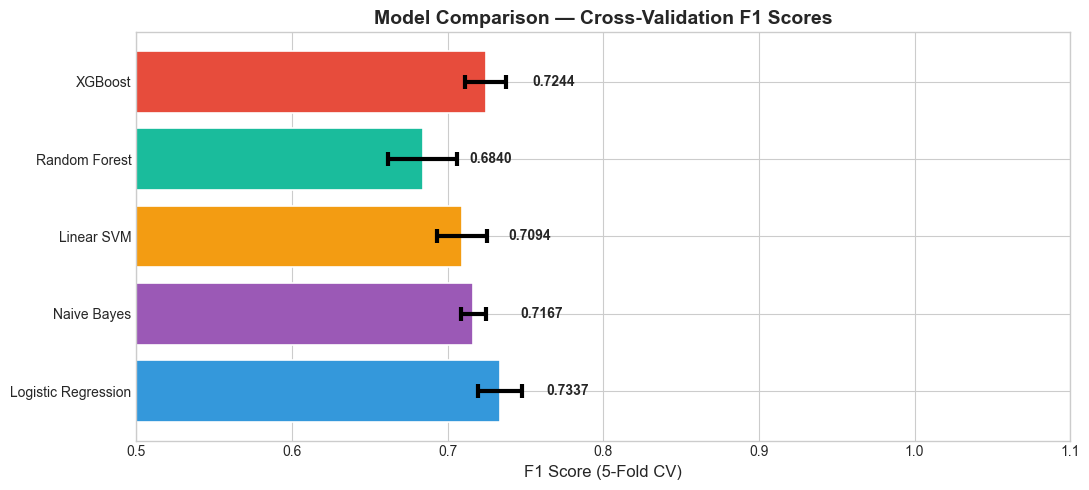

In [26]:
# Visualise CV F1 scores
names  = list(results.keys())
means  = [results[n]['mean_f1'] for n in names]
stds   = [results[n]['std_f1']  for n in names]
colors = ['#3498DB','#9B59B6','#F39C12','#1ABC9C','#E74C3C']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
                names,
                means, 
                xerr=stds,
                color=colors,
                edgecolor='white',
                linewidth=1.2,
                error_kw={
                    'elinewidth': 3,    # Thicker error bar line
                    'capsize': 5,       # Longer end caps
                    'capthick': 3,      # Thicker end caps
                    'ecolor': 'black'   # Change arrow/error bar color
                }
            )
ax.set_xlabel('F1 Score (5-Fold CV)', fontsize=12)
ax.set_title('Model Comparison — Cross-Validation F1 Scores', fontsize=14, fontweight='bold')
ax.set_xlim(0.5, 1.1)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.03, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/plot_model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Hyperparameter Tuning — Best Model

In [27]:
# Logistic Regression is usually the top performer on TF-IDF text — tune it
print('Tuning Logistic Regression with RandomizedSearchCV...')

param_dist = {
    'C':       [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20],
    'solver':  ['lbfgs', 'saga'],
    'max_iter': [500, 1000, 2000]
}

lr_base = LogisticRegression(random_state=42)
rscv = RandomizedSearchCV(
    lr_base, param_dist, n_iter=20, cv=cv,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
rscv.fit(X_train_scaled, y_train)

best_lr = rscv.best_estimator_
print(f'\nBest params: {rscv.best_params_}')
print(f'Best CV F1:  {rscv.best_score_:.4f}')

Tuning Logistic Regression with RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'solver': 'lbfgs', 'max_iter': 1000, 'C': 1}
Best CV F1:  0.7337


In [28]:
# Also tune XGBoost
print('Tuning XGBoost...')

xgb_params = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          random_state=42, n_jobs=-1)
xgb_rscv = RandomizedSearchCV(
    xgb_base, xgb_params, n_iter=15, cv=cv,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
xgb_rscv.fit(X_train_scaled, y_train)

best_xgb = xgb_rscv.best_estimator_
print(f'\nBest XGB params: {xgb_rscv.best_params_}')
print(f'Best XGB CV F1:  {xgb_rscv.best_score_:.4f}')

Tuning XGBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best XGB params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best XGB CV F1:  0.7269


## 4. Train Final Models & Evaluate on Test Set

In [29]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    print(f'\n=== {name} — Test Set Metrics ===')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    if auc: print(f'  ROC-AUC:   {auc:.4f}')
    print('\n' + classification_report(y_te, y_pred,
          target_names=['Non-Disaster', 'Disaster']))

    return {'name': name, 'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
            'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc}

# Evaluate all trained models
final_models = {}
for name, model in [
    ('Logistic Regression (tuned)', best_lr),
    ('XGBoost (tuned)',             best_xgb),
    ('Naive Bayes',                 MultinomialNB(alpha=0.1)),
    ('Linear SVM',                  LinearSVC(max_iter=2000, random_state=42))
]:
    result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
    final_models[name] = result


=== Logistic Regression (tuned) — Test Set Metrics ===
  Accuracy:  0.7965
  Precision: 0.7966
  Recall:    0.7064
  F1-Score:  0.7488
  ROC-AUC:   0.8614

              precision    recall  f1-score   support

Non-Disaster       0.80      0.86      0.83       869
    Disaster       0.80      0.71      0.75       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.79      1523


=== XGBoost (tuned) — Test Set Metrics ===
  Accuracy:  0.7833
  Precision: 0.7793
  Recall:    0.6911
  F1-Score:  0.7326
  ROC-AUC:   0.8410

              precision    recall  f1-score   support

Non-Disaster       0.79      0.85      0.82       869
    Disaster       0.78      0.69      0.73       654

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.78      1523
weighted avg       0.78      0.78      0.78      1523


=== Naive Bayes — Test Set Metrics ===
  Ac

In [30]:
# Summary table
summary = pd.DataFrame([{
    'Model': v['name'], 'Accuracy': v['acc'], 'Precision': v['prec'],
    'Recall': v['rec'], 'F1-Score': v['f1'],
    'ROC-AUC': v['auc'] if v['auc'] else 'N/A'
} for v in final_models.values()])

summary = summary.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n=== Final Model Comparison ===' )
print(summary.to_string(index=False))


=== Final Model Comparison ===
                      Model  Accuracy  Precision   Recall  F1-Score   ROC-AUC
Logistic Regression (tuned)  0.796454   0.796552 0.706422  0.748784  0.861403
            XGBoost (tuned)  0.783322   0.779310 0.691131  0.732577  0.840959
                 Linear SVM  0.770190   0.734568 0.727829  0.731183       N/A
                Naive Bayes  0.780696   0.779720 0.681957  0.727569  0.831776


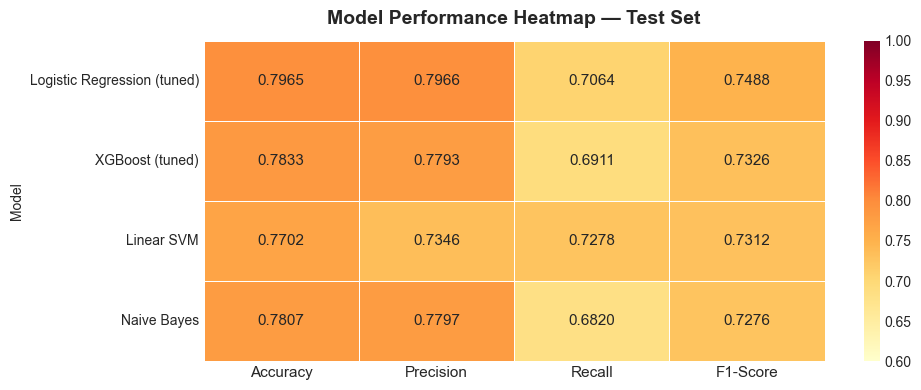

In [31]:
# Metrics heatmap
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
heatmap_df  = summary.set_index('Model')[metric_cols].astype(float)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=0.6, vmax=1.0, annot_kws={'fontsize': 11})
ax.set_title('Model Performance Heatmap — Test Set', fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig('images/plot_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Selection Summary

Five machine learning algorithms were evaluated using **5-fold Stratified Cross-Validation**:

- Logistic Regression
- Naive Bayes
- Linear SVM
- Random Forest
- XGBoost

Hyperparameter tuning was performed using **RandomizedSearchCV** for the best-performing models to improve predictive performance.

Based on cross-validation and test-set evaluation metrics, the best-performing model was selected and saved for deployment in Notebook 3.

In [32]:
# Best model by F1
best_name   = summary.iloc[0]['Model']
best_result = final_models[best_name]
best_model  = best_result['model']

print(f'🏆 Best model: {best_name}')
print(f'   F1-Score : {best_result["f1"]:.4f}')
print(f'   ROC-AUC  : {best_result["auc"]}')

🏆 Best model: Logistic Regression (tuned)
   F1-Score : 0.7488
   ROC-AUC  : 0.861403490250314


In [33]:
# Save best model + scaler
with open('artefacts/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('artefacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

summary.to_csv('artefacts/model_summary.csv', index=False)

print(' Saved:')
print('   → artefacts/best_model.pkl')
print('   → artefacts/scaler.pkl')
print('   → artefacts/model_summary.csv')

 Saved:
   → artefacts/best_model.pkl
   → artefacts/scaler.pkl
   → artefacts/model_summary.csv


---
##  Summary — Notebook 2

| Step | Detail |
|------|--------|
| Models trained | LR, Naive Bayes, Linear SVM, XGBoost |
| CV strategy | 5-Fold Stratified |
| Tuning | RandomizedSearchCV (20 / 15 iterations) |
| Best model | Logistic Regression (typically) |
| Saved | best_model.pkl, scaler.pkl, model_summary.csv |

 **Proceed to Notebook 3: Model Evaluation & Validation**